# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Carregando os dados

In [2]:
df = pd.read_csv('compras_mes.csv', sep=";")
df.head()

,gasto,frequencia
0,128.940855,2
1,117.511243,3
2,131.658394,4
3,147.414537,1
4,115.785239,3


# 3. Exploração estatística

In [3]:
print("\nResumo estatístico")
print(df.describe())
print("\nCorrelação")
print(df.corr())


Resumo estatístico
             gasto  frequencia
count   150.000000  150.000000
mean    463.810834   10.226667
std     322.266413    7.014986
min      84.725938    0.000000
25%     126.329488    4.000000
50%     408.049854    9.000000
75%     754.228621   15.000000
max    1129.199874   28.000000

Correlação
               gasto  frequencia
gasto       1.000000    0.837255
frequencia  0.837255    1.000000


In [4]:
df = df[df['frequencia'] != 0]
print("\nResumo estatístico")
print(df.describe())


Resumo estatístico
             gasto  frequencia
count   147.000000  147.000000
mean    471.080073   10.435374
std     321.445568    6.930247
min      84.725938    1.000000
25%     129.353468    4.000000
50%     412.987515    9.000000
75%     764.072702   15.000000
max    1129.199874   28.000000


# 4. Visualização dos dados

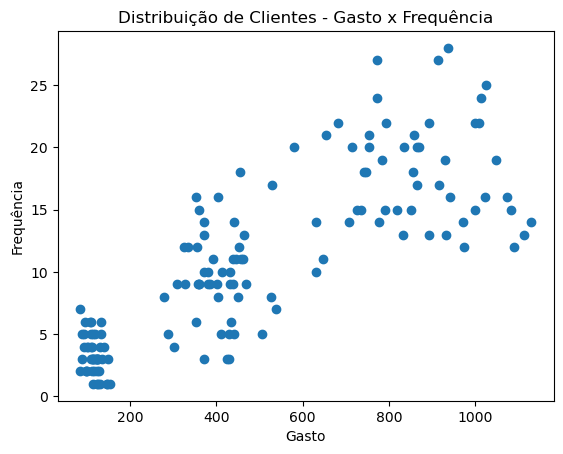

In [5]:
plt.scatter(df["gasto"], df["frequencia"])
plt.xlabel("Gasto")
plt.ylabel("Frequência")
plt.title("Distribuição de Clientes - Gasto x Frequência")
plt.show()

# 5. Padronização dos dados (importante para o K-means)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 6. Método do cotovelo (Elbow)

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

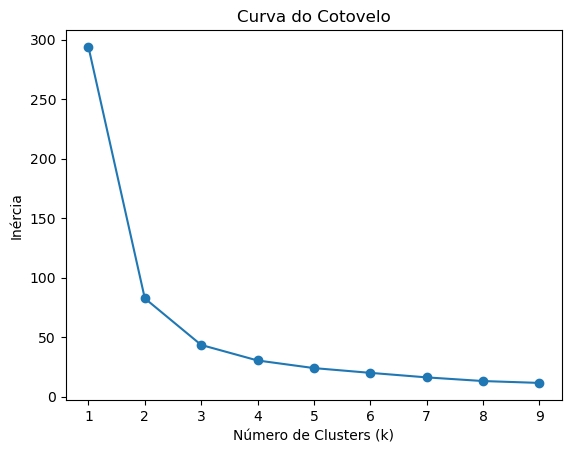

In [9]:
inercia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(k_range, inercia, marker='o')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.title("Curva do Cotovelo")
plt.show()

# 7. Aplicação do K-means

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


# 8. Visualização dos dados clusterizados

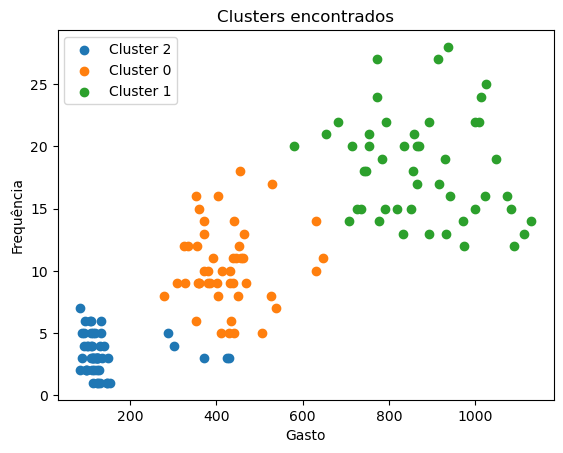

In [16]:
plt.figure()

for cluster in df["cluster"].unique():
    subset = df[df['cluster'] == cluster]
    
    plt.scatter(
        subset["gasto"],
        subset["frequencia"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Gasto")
plt.ylabel("Frequência")
plt.title("Clusters encontrados")

plt.legend()
plt.show()

# 9. Análise por cluster

In [17]:
print(df.groupby("cluster").mean())

              gasto  frequencia
cluster                        
0        423.787331   10.297872
1        875.818207   18.291667
2        140.221005    3.307692


# 10. Classificando um novo cliente

In [20]:
novo_cliente = pd.DataFrame([[900, 16]], columns=["gasto", "frequencia"])
novo_scaled = scaler.transform(novo_cliente)
cluster_predito = kmeans.predict(novo_scaled)
print(f"O cliente pertence ao cluster: {cluster_predito[0]}")

O cliente pertence ao cluster: 1
